# Regularized Logistic Regression from Scratch
We implements logistic regression with L2 regularization, grid search, and 5-fold cross-validation using the Breast Cancer dataset.

In [1]:
# Import libraries
# sklearn.datasets: ONLY for loading dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

In [2]:
# Load dataset 
X, y = load_breast_cancer(return_X_y=True)

df = pd.DataFrame(X)
df['target'] = y
print("Preview of dataset:")
print(df.head())

print("\nDataset shape:", df.shape)

Preview of dataset:
       0      1       2       3        4        5       6        7       8  \
0  17.99  10.38  122.80  1001.0  0.11840  0.27760  0.3001  0.14710  0.2419   
1  20.57  17.77  132.90  1326.0  0.08474  0.07864  0.0869  0.07017  0.1812   
2  19.69  21.25  130.00  1203.0  0.10960  0.15990  0.1974  0.12790  0.2069   
3  11.42  20.38   77.58   386.1  0.14250  0.28390  0.2414  0.10520  0.2597   
4  20.29  14.34  135.10  1297.0  0.10030  0.13280  0.1980  0.10430  0.1809   

         9  ...     21      22      23      24      25      26      27  \
0  0.07871  ...  17.33  184.60  2019.0  0.1622  0.6656  0.7119  0.2654   
1  0.05667  ...  23.41  158.80  1956.0  0.1238  0.1866  0.2416  0.1860   
2  0.05999  ...  25.53  152.50  1709.0  0.1444  0.4245  0.4504  0.2430   
3  0.09744  ...  26.50   98.87   567.7  0.2098  0.8663  0.6869  0.2575   
4  0.05883  ...  16.67  152.20  1575.0  0.1374  0.2050  0.4000  0.1625   

       28       29  target  
0  0.4601  0.11890       0  
1  0.275

In [3]:
# Split dataset into training and testing sets
indices = np.random.permutation(len(y))
split = int(0.8 * len(y))
train_idx, test_idx = indices[:split], indices[split:]
X_train_raw, X_test_raw = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

In [14]:
# Normalize features using TRAINING statistics only (prevent data leakage)
mean = X_train_raw.mean(axis=0)
std  = X_train_raw.std(axis=0)

X_train_norm = (X_train_raw - mean) / std
X_test_norm  = (X_test_raw  - mean) / std

# Add bias term (column of ones)
X_train = np.c_[np.ones(X_train_norm.shape[0]), X_train_norm]
X_test  = np.c_[np.ones(X_test_norm.shape[0]),  X_test_norm]

In [5]:
# Sigmoid function TO Converts any number → probability (0 to 1) and prevent overflow
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

In [6]:
# Cost function with L2 regularization
def compute_cost(X, y, theta, lam):
    m = len(y)
    h = sigmoid(X @ theta)
    epsilon = 1e-5  # prevent log(0)

    cost = (-1/m) * np.sum(y*np.log(h+epsilon) + (1-y)*np.log(1-h+epsilon))
    reg = (lam/(2*m)) * np.sum(theta[1:]**2)

    return cost + reg

In [7]:
# Gradient Descent to optimize parameters & Repeats many times to minimize error
def gradient_descent(X, y, theta, lr, lam, iterations):
    m = len(y)

    for i in range(iterations):
        h = sigmoid(X @ theta)
        gradient = (1/m) * (X.T @ (h - y))

        # Apply regularization (skip bias)
        gradient[1:] += (lam/m) * theta[1:]

        theta -= lr * gradient

    return theta

In [8]:
# Predict class labels
def predict(X, theta):
    probs = sigmoid(X @ theta)
    return (probs >= 0.5).astype(int)

In [9]:
# Compute confusion matrix
def confusion_matrix(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))    #TP → correct positive
    TN = np.sum((y_true == 0) & (y_pred == 0))   #TN → correct negative
    FP = np.sum((y_true == 0) & (y_pred == 1))   #FP → wrong positive
    FN = np.sum((y_true == 1) & (y_pred == 0))   #FN → wrong negative
    return TP, TN, FP, FN

In [10]:
# Split data into K folds
def k_fold_split(X, y, k=5):
    indices = np.arange(len(y))
    np.random.shuffle(indices)
    return np.array_split(indices, k)

In [11]:
# Grid search with 5-fold cross-validation
def grid_search(X, y, lambdas, k=5):
    folds = k_fold_split(X, y, k)
    best_lambda = None
    best_score = -1

    for lam in lambdas:
        scores = []

        for i in range(k):
            val_idx = folds[i]
            train_idx = np.concatenate([folds[j] for j in range(k) if j != i])

            X_train, y_train = X[train_idx], y[train_idx]
            X_val, y_val = X[val_idx], y[val_idx]

            theta = np.zeros(X.shape[1])
            theta = gradient_descent(X_train, y_train, theta, lr=0.01, lam=lam, iterations=1000)

            preds = predict(X_val, theta)
            accuracy = np.mean(preds == y_val)
            scores.append(accuracy)

        avg_score = np.mean(scores)
        print(f"Lambda: {lam}, CV Accuracy: {avg_score:.4f}")

        if avg_score > best_score:
            best_score = avg_score
            best_lambda = lam

    return best_lambda, best_score

In [12]:
# Try different regularization values
lambdas = [0.001, 0.01, 0.1, 1, 10, 100]

best_lambda, best_score = grid_search(X, y, lambdas)

print("\nBest Lambda:", best_lambda)
print("Best CV Accuracy:", best_score)

Lambda: 0.001, CV Accuracy: 0.9068
Lambda: 0.01, CV Accuracy: 0.9104
Lambda: 0.1, CV Accuracy: 0.9120
Lambda: 1, CV Accuracy: 0.9050
Lambda: 10, CV Accuracy: 0.8699
Lambda: 100, CV Accuracy: 0.8243

Best Lambda: 0.1
Best CV Accuracy: 0.9120322931221858


In [18]:
# Train final model on full training set using best lambda
theta_final = np.zeros(X_train.shape[1])
theta_final = gradient_descent(X_train, y_train, theta_final,
                               lr=0.1, lam=best_lambda, iterations=1000)

In [20]:
# Evaluate on held-out test set
preds_test = predict(X_test, theta_final)
TP, TN, FP, FN = confusion_matrix(y_test, preds_test)

accuracy  = (TP + TN) / len(y_test)

# Per-class accuracy
acc_class0 = TN / (TN + FP) if (TN + FP) > 0 else 0  # out of all actual Malignant, how many did we catch?
acc_class1 = TP / (TP + FN) if (TP + FN) > 0 else 0  # out of all actual Benign, how many did we get right?
avg_per_class_acc = (acc_class0 + acc_class1) / 2

print("Test Set Results")
print("-" * 35)
print(f"  True Positives  (TP) : {TP}")
print(f"  True Negatives  (TN) : {TN}")
print(f"  False Positives (FP) : {FP}")
print(f"  False Negatives (FN) : {FN}")
print("-" * 35)
print(f"  Overall Accuracy       : {accuracy:.4f}")
print(f"  Malignant Accuracy     : {acc_class0:.4f}")
print(f"  Benign Accuracy        : {acc_class1:.4f}")
print(f"  Avg Per-Class Accuracy : {avg_per_class_acc:.4f}")
print("-" * 35)


Test Set Results
-----------------------------------
  True Positives  (TP) : 68
  True Negatives  (TN) : 46
  False Positives (FP) : 0
  False Negatives (FN) : 0
-----------------------------------
  Overall Accuracy       : 1.0000
  Malignant Accuracy     : 1.0000
  Benign Accuracy        : 1.0000
  Avg Per-Class Accuracy : 1.0000
-----------------------------------


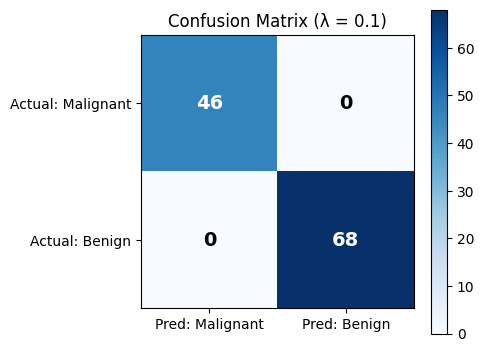

In [19]:
# Plot confusion matrix
cm = np.array([[TN, FP],
               [FN, TP]])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred: Malignant', 'Pred: Benign'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Actual: Malignant', 'Actual: Benign'])
ax.set_title(f'Confusion Matrix (λ = {best_lambda})')

# Adaptive text color
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > thresh else "black"
        ax.text(j, i, cm[i, j], ha="center", va="center",
                fontsize=14, fontweight='bold', color=color)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

We now replicate the same experiment using `sklearn` to verify our from-scratch implementation produces comparable results.

In [21]:
# sklearn imports — ONLY used here for verification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import confusion_matrix as sk_confusion_matrix, classification_report

In [24]:
# Use the same normalized train/test split (no bias column needed for sklearn)
X_train_sk = X_train_norm   # already normalized, no bias term
X_test_sk  = X_test_norm

# Grid search with 5-fold CV — mirrors our custom implementation
C_values = [1/lam for lam in [0.001, 0.01, 0.1, 1, 10, 100]]

sk_model = LogisticRegression(solver='lbfgs', max_iter=1000)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sk_grid = GridSearchCV(sk_model, {'C': C_values}, cv=cv, scoring='accuracy')
sk_grid.fit(X_train_sk, y_train)

print("Sklearn Grid Search Results:")
for params, score in zip(sk_grid.cv_results_['params'], sk_grid.cv_results_['mean_test_score']):
    lam = 1 / params['C']
    print(f"  Lambda: {lam:.4f}  |  CV Accuracy: {score:.4f}")

best_C = sk_grid.best_params_['C']
print(f"\nBest Lambda (sklearn): {1/best_C:.4f}")
print(f"Best CV Accuracy     : {sk_grid.best_score_:.4f}")

Sklearn Grid Search Results:
  Lambda: 0.0010  |  CV Accuracy: 0.9451
  Lambda: 0.0100  |  CV Accuracy: 0.9538
  Lambda: 0.1000  |  CV Accuracy: 0.9626
  Lambda: 1.0000  |  CV Accuracy: 0.9648
  Lambda: 10.0000  |  CV Accuracy: 0.9736
  Lambda: 100.0000  |  CV Accuracy: 0.9538

Best Lambda (sklearn): 10.0000
Best CV Accuracy     : 0.9736


Sklearn Test Set Results
-----------------------------------
  True Positives  (TP) : 68
  True Negatives  (TN) : 44
  False Positives (FP) : 2
  False Negatives (FN) : 0
-----------------------------------
  Overall Accuracy       : 0.9825
  Malignant Accuracy     : 0.9565
  Benign Accuracy        : 1.0000
  Avg Per-Class Accuracy : 0.9783
-----------------------------------


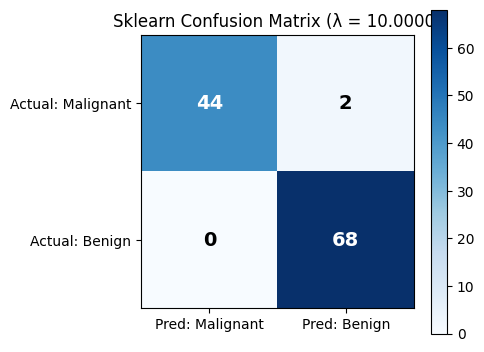

In [25]:
# Evaluate sklearn best model on test set
sk_best  = sk_grid.best_estimator_
sk_preds = sk_best.predict(X_test_sk)

sk_cm              = sk_confusion_matrix(y_test, sk_preds)
sk_TN, sk_FP, sk_FN, sk_TP = sk_cm.ravel()

sk_acc        = (sk_TP + sk_TN) / len(y_test)
sk_acc_class0 = sk_TN / (sk_TN + sk_FP) if (sk_TN + sk_FP) > 0 else 0
sk_acc_class1 = sk_TP / (sk_TP + sk_FN) if (sk_TP + sk_FN) > 0 else 0
sk_avg        = (sk_acc_class0 + sk_acc_class1) / 2

print("Sklearn Test Set Results")
print("-" * 35)
print(f"  True Positives  (TP) : {sk_TP}")
print(f"  True Negatives  (TN) : {sk_TN}")
print(f"  False Positives (FP) : {sk_FP}")
print(f"  False Negatives (FN) : {sk_FN}")
print("-" * 35)
print(f"  Overall Accuracy       : {sk_acc:.4f}")
print(f"  Malignant Accuracy     : {sk_acc_class0:.4f}")
print(f"  Benign Accuracy        : {sk_acc_class1:.4f}")
print(f"  Avg Per-Class Accuracy : {sk_avg:.4f}")
print("-" * 35)

# Plot sklearn confusion matrix
sk_cm_plot = np.array([[sk_TN, sk_FP],
                        [sk_FN, sk_TP]])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(sk_cm_plot, cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred: Malignant', 'Pred: Benign'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Actual: Malignant', 'Actual: Benign'])
ax.set_title(f'Sklearn Confusion Matrix (λ = {1/best_C:.4f})')

thresh = sk_cm_plot.max() / 2
for i in range(2):
    for j in range(2):
        color = "white" if sk_cm_plot[i, j] > thresh else "black"
        ax.text(j, i, sk_cm_plot[i, j], ha="center", va="center",
                fontsize=14, fontweight='bold', color=color)

plt.tight_layout()
plt.savefig('sklearn_confusion_matrix.png', dpi=150)
plt.show()